In [1]:
from visualizations import spike_plot_4x2, sixteen_tuning_curves, mean_var_scatter_4x4, mean_var_scatter_4x4_regression, violin_4row, violin_combined
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime
from matplotlib.ticker import MultipleLocator

### loading data

In [2]:
# in real code we now labels_lst from np.unique() on region label output from predictions
labels_lst = [1,2,3,4]

string_path = 'fnn//input_noise//saved_inputs_outputs//predictions_july21//' # ex. path to predictions used from july

for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin', 'no_noise']:
    for type_noise in ['_sum', '_mean', '_var', '_labels']:
        file_name = string_path + noise + type_noise + '.npy'
        arr_name = noise + type_noise
        globals()[arr_name] = np.load(file_name)

# load predictions by region
for r in labels_lst:
    for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin', 'no_noise']:
        for type_noise in ['_sum', '_mean', '_var']:
            file_name = string_path + noise + type_noise + '_r' + str(r) + '.npy'
            arr_name = noise + type_noise + '_r' + str(r)
            globals()[arr_name] = np.load(file_name)

### making arrays

In [10]:
cmeans = [[c3_mean_r1, c15_mean_r1, c30_mean_r1, cbin_mean_r1],
                 [c3_mean_r2, c15_mean_r2, c30_mean_r2, cbin_mean_r2],
                 [c3_mean_r3, c15_mean_r3, c30_mean_r3, cbin_mean_r3],
                 [c3_mean_r4, c15_mean_r4, c30_mean_r4, cbin_mean_r4]]

cvars = [[c3_var_r1, c15_var_r1, c30_var_r1, cbin_var_r1],
               [c3_var_r2, c15_var_r2, c30_var_r2, cbin_var_r2],
               [c3_var_r3, c15_var_r3, c30_var_r3, cbin_var_r3],
               [c3_var_r4, c15_var_r4, c30_var_r4, cbin_var_r4]]

In [11]:
dmeans = [[d3_mean_r1, d15_mean_r1, d30_mean_r1, dbin_mean_r1],
                 [d3_mean_r2, d15_mean_r2, d30_mean_r2, dbin_mean_r2],
                 [d3_mean_r3, d15_mean_r3, d30_mean_r3, dbin_mean_r3],
                 [d3_mean_r4, d15_mean_r4, d30_mean_r4, dbin_mean_r4]]

dvars = [[d3_var_r1, d15_var_r1, d30_var_r1, dbin_var_r1],
               [d3_var_r2, d15_var_r2, d30_var_r2, dbin_var_r2],
               [d3_var_r3, d15_var_r3, d30_var_r3, dbin_var_r3],
               [d3_var_r4, d15_var_r4, d30_var_r4, dbin_var_r4]]

In [5]:
cviolin_means = [[c15_mean_r1, c30_mean_r1, cbin_mean_r1],
                 [c15_mean_r2, c30_mean_r2, cbin_mean_r2],
                 [c15_mean_r3, c30_mean_r3, cbin_mean_r3],
                 [c15_mean_r4, c30_mean_r4, cbin_mean_r4]]

cviolin_vars = [[c15_var_r1, c30_var_r1, cbin_var_r1],
                [c15_var_r2, c30_var_r2, cbin_var_r2],
                [c15_var_r3, c30_var_r3, cbin_var_r3],
                [c15_var_r4, c30_var_r4, cbin_var_r4]]

In [6]:
dviolin_means = [[d15_mean_r1, d30_mean_r1, dbin_mean_r1],
                 [d15_mean_r2, d30_mean_r2, dbin_mean_r2],
                 [d15_mean_r3, d30_mean_r3, dbin_mean_r3],
                 [d15_mean_r4, d30_mean_r4, dbin_mean_r4]]

dviolin_vars = [[d15_var_r1, d30_var_r1, dbin_var_r1],
                [d15_var_r2, d30_var_r2, dbin_var_r2],
                [d15_var_r3, d30_var_r3, dbin_var_r3],
                [d15_var_r4, d30_var_r4, dbin_var_r4]]

### plots

#### line plots

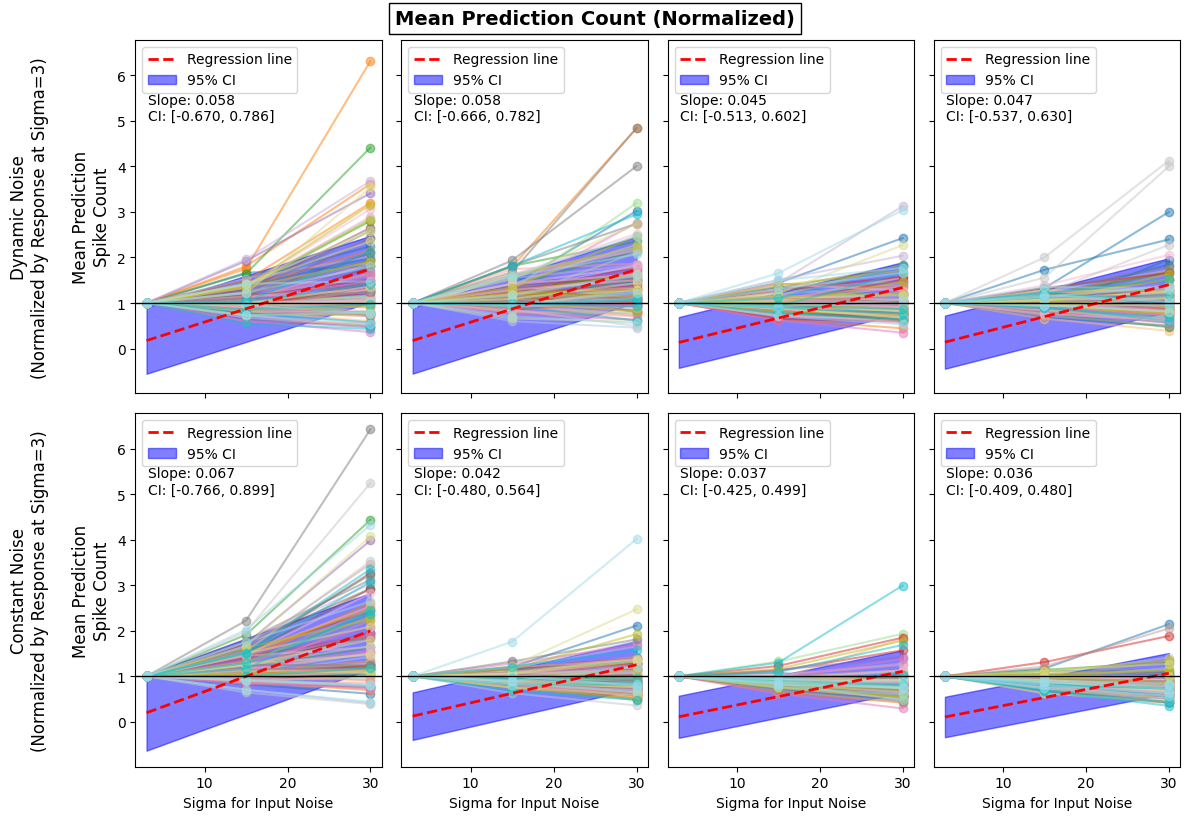

In [12]:
spike_plot_4x2('Mean Prediction Count (Normalized)', dmeans, cmeans, True)

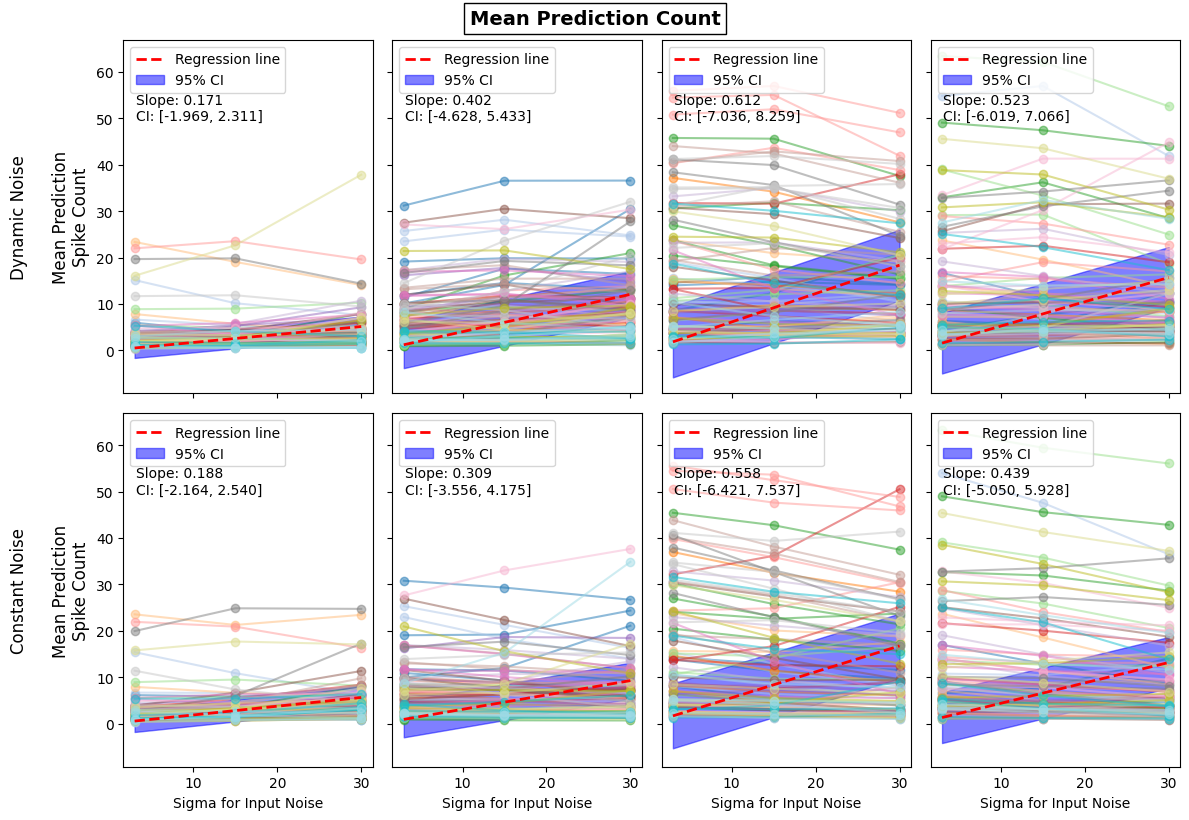

In [7]:
spike_plot_4x2('Mean Prediction Count', dmeans, cmeans, False)

#### tuning curves

In [ ]:
csums = [[c3_sum_r1, c15_sum_r1, c30_sum_r1, cbin_sum_r1],
                 [c3_sum_r2, c15_sum_r2, c30_sum_r2, cbin_sum_r2],
                 [c3_sum_r3, c15_sum_r3, c30_sum_r3, cbin_sum_r3],
                 [c3_sum_r4, c15_sum_r4, c30_sum_r4, cbin_sum_r4]]

In [ ]:
tuning_titles = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']

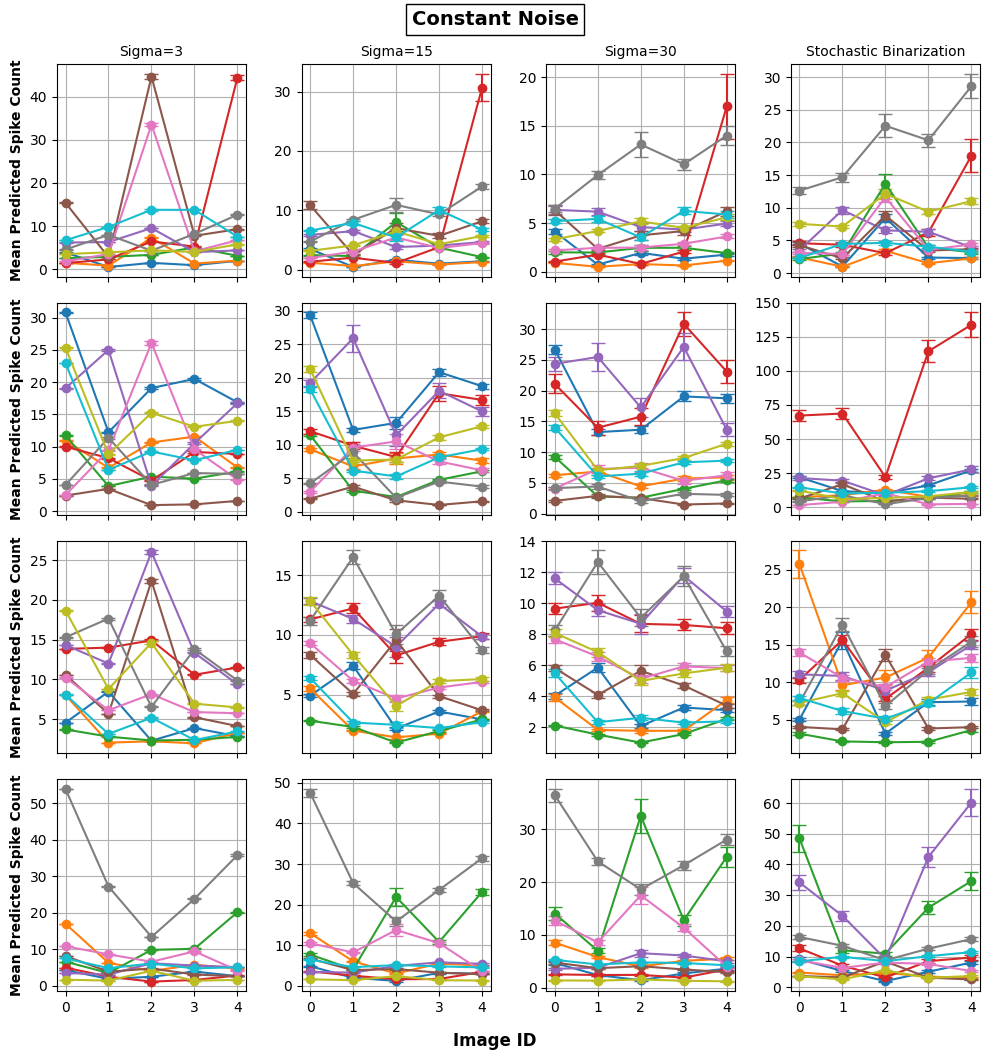

In [ ]:
sixteen_tuning_curves(csums, 'Constant Noise', tuning_titles)

In [ ]:
dsums = [[d3_sum_r1, d15_sum_r1, d30_sum_r1, dbin_sum_r1],
                 [d3_sum_r2, d15_sum_r2, d30_sum_r2, dbin_sum_r2],
                 [d3_sum_r3, d15_sum_r3, d30_sum_r3, dbin_sum_r3],
                 [d3_sum_r4, d15_sum_r4, d30_sum_r4, dbin_sum_r4]]

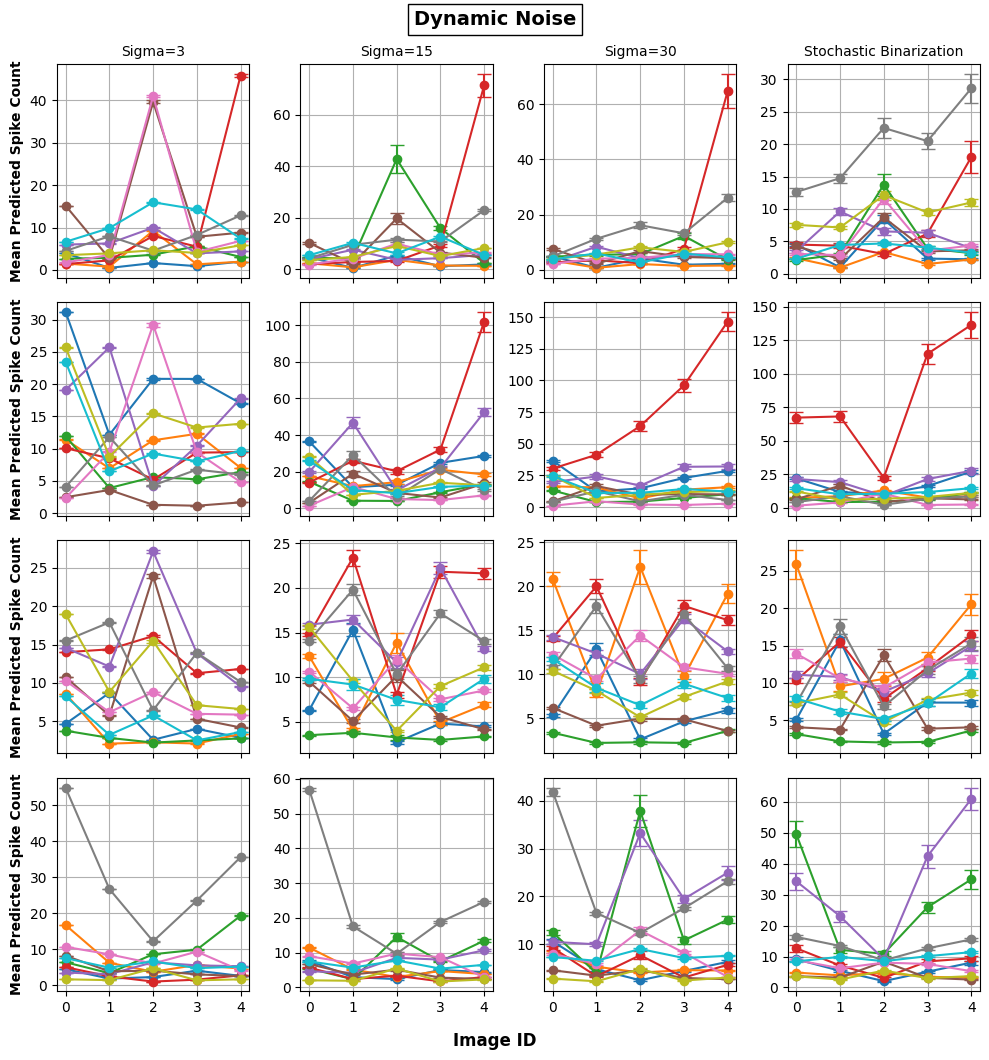

In [ ]:
sixteen_tuning_curves(dsums, 'Dynamic Noise', tuning_titles)

#### mean var scatter

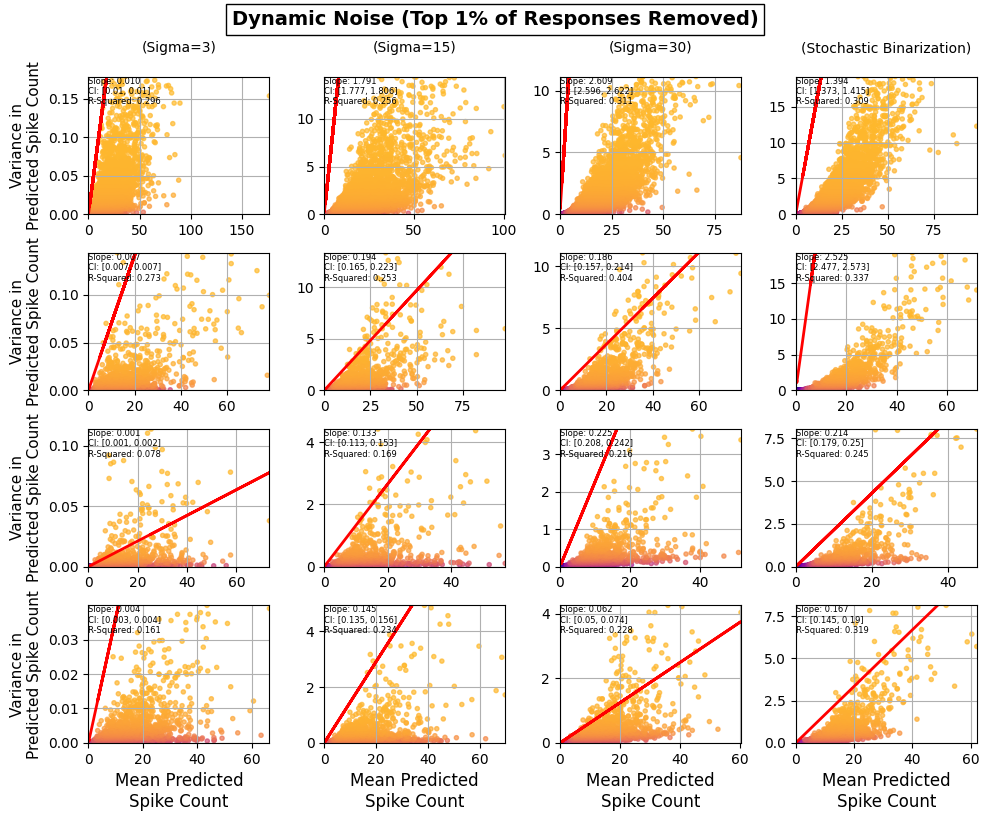

In [ ]:
# run arrays before this cell
mean_var_scatter_4x4(dmeans, dvars, 'Dynamic Noise (Top 1% of Responses Removed)', False, 'top', 1)

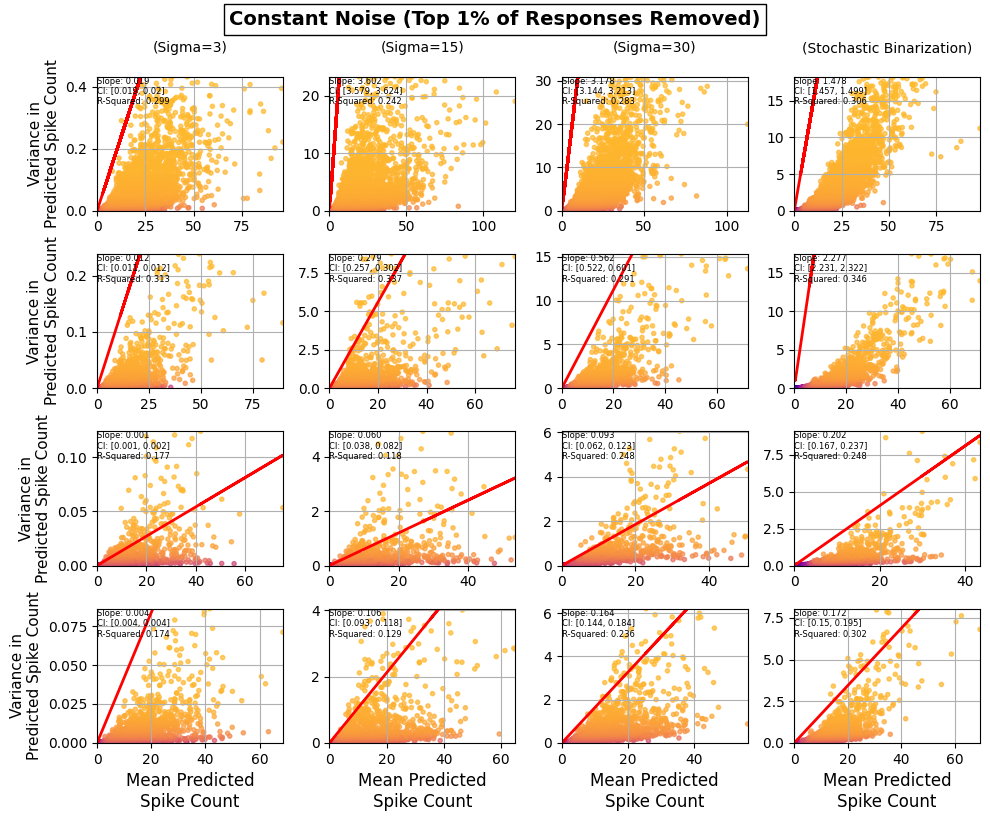

In [ ]:
mean_var_scatter_4x4(cmeans, cvars, 'Constant Noise (Top 1% of Responses Removed)', False, 'top', 1)

#### mean var scatter regression

In [ ]:
# region 1
r1_randoms = [2322, 3279, 4060, 1756,  146, 4441, 3978, 2034, 5025, 3515, 3534,
       2167, 2310, 1837, 3864, 2529, 4127, 2325, 4791,  314, 3371, 1857,
       1095, 1917, 3097, 1722, 4344, 3627, 3930, 3459]
# region 2
r2_randoms = [958, 907, 514, 432, 594, 385, 184, 368, 525, 351, 302, 551, 550,
       575, 375, 719, 242, 613, 789, 872, 340, 402, 397, 643, 255, 928,
       471, 894, 281, 523]
# region 3
r3_randoms = [279, 337, 208, 128,  46, 115, 248, 197,  52, 269,  37, 364, 340,
       203,  36, 153,  84, 278,  71, 115,  24,  78, 138,  38,  22,  17,
        89, 349, 178, 332]
# region 4
r4_randoms = [376, 295, 517,  25, 663, 429, 427, 651, 133, 500, 689, 266, 470,
       424,  90, 560, 290, 198, 149, 181, 749, 461, 658, 771, 367, 758,
       125, 195, 191,   8]

randoms = [r1_randoms, r2_randoms, r3_randoms, r4_randoms]

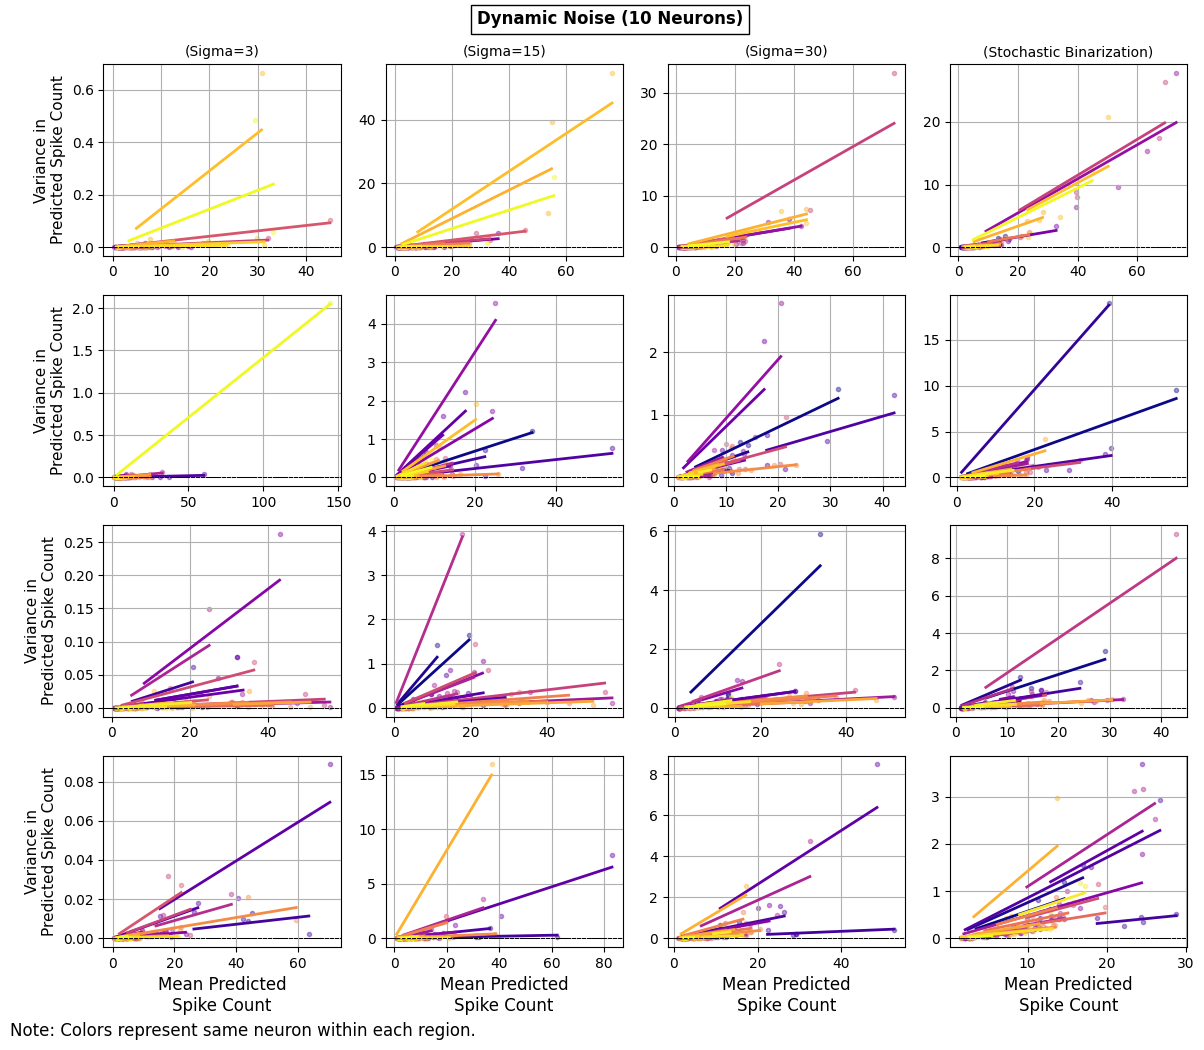

In [ ]:
mean_var_scatter_4x4_regression(dmeans, dvars, randoms, 'Dynamic Noise (10 Neurons)')

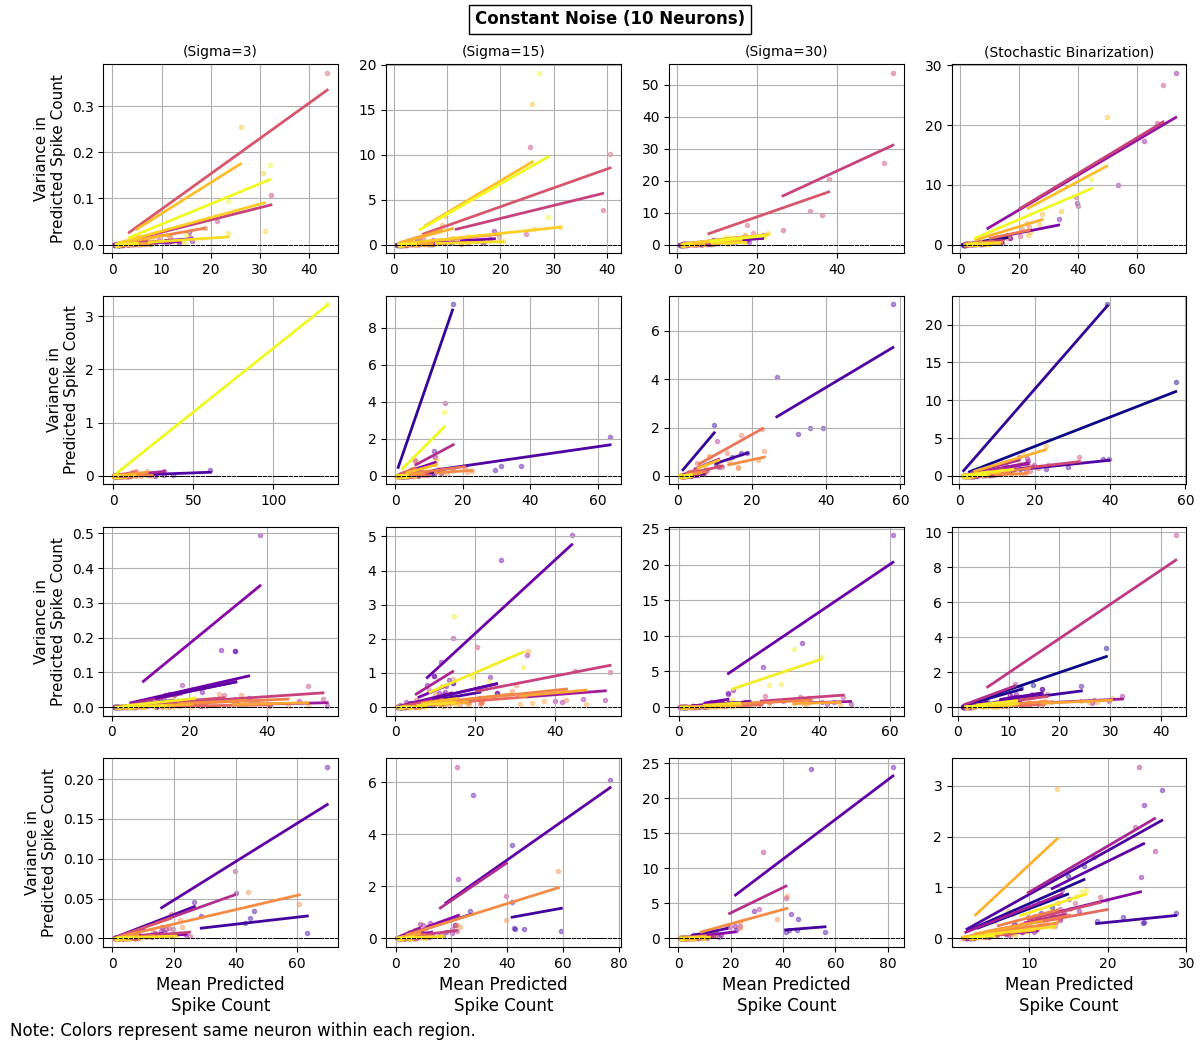

In [ ]:
mean_var_scatter_4x4_regression(cmeans, cvars, randoms, 'Constant Noise (10 Neurons)')

#### violin 1

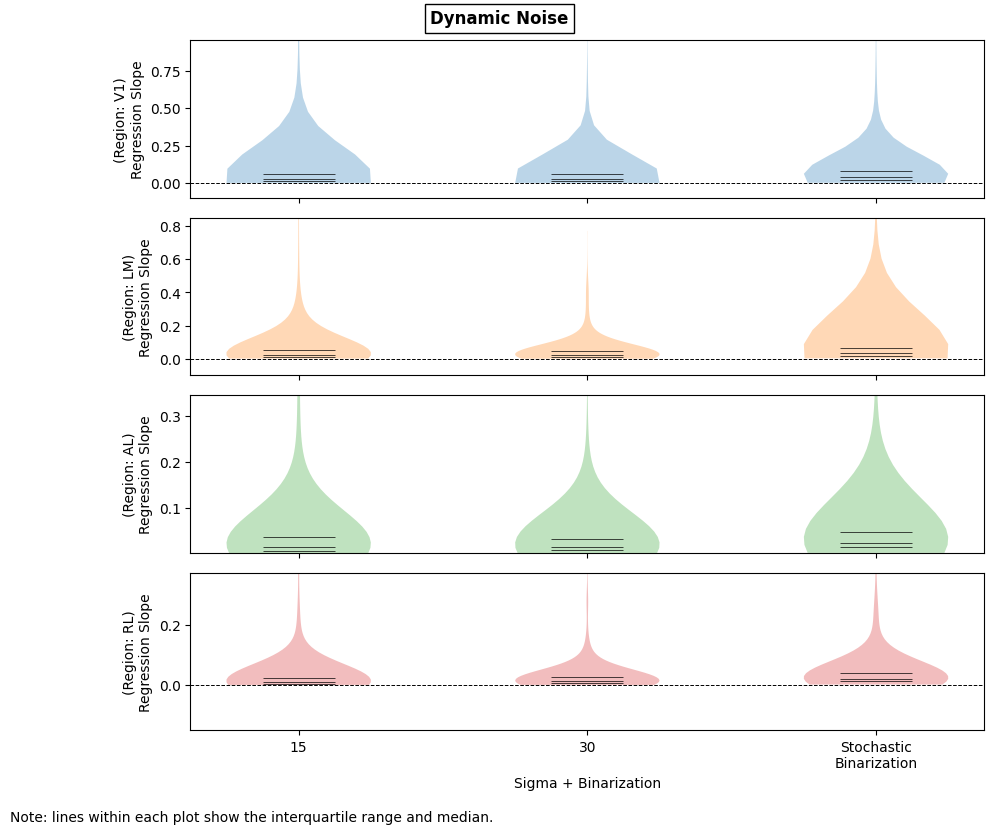

In [7]:
violin_4row(dviolin_means, dviolin_vars, 'Dynamic Noise')

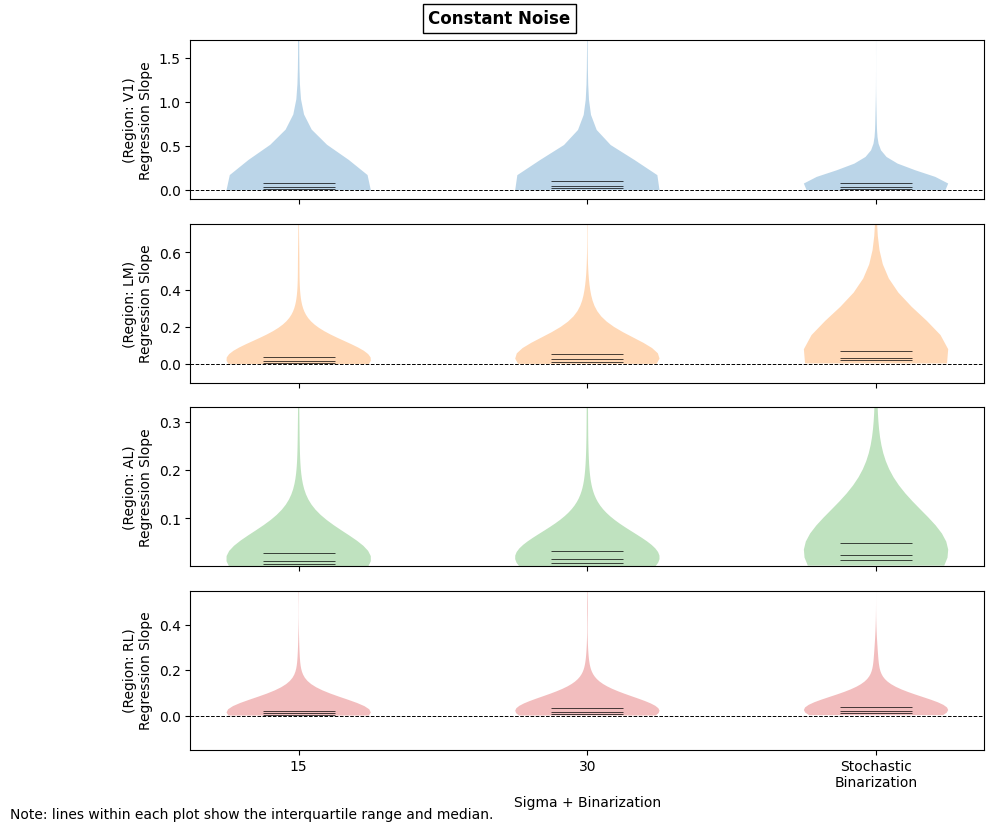

In [ ]:
violin_4row(cviolin_means, cviolin_vars, 'Constant Noise')

#### violin 2

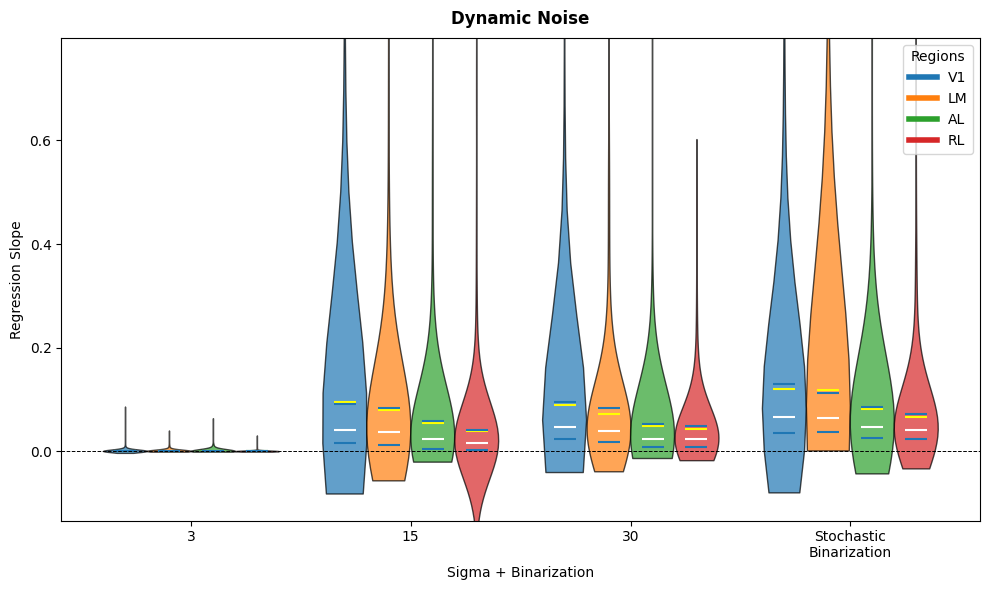

In [8]:
violin_combined(dmeans, dvars, 'Dynamic Noise')

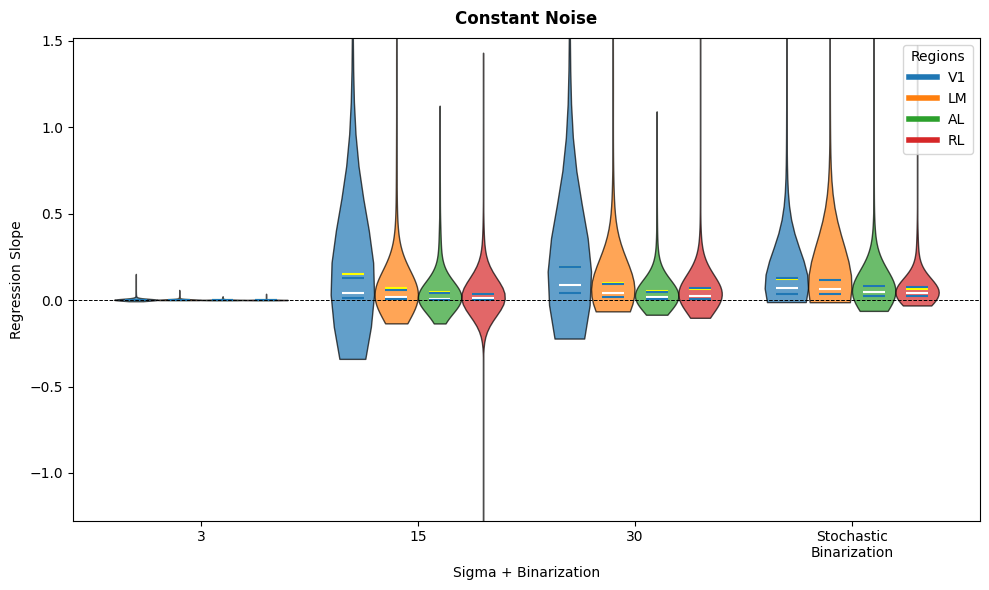

In [9]:
violin_combined(cmeans, cvars, 'Constant Noise')